[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day4_LULC_and_Climate_with_RS/01_classification_fundamentals_and_algorithms.ipynb)

# Day 4 - Land Use / Land Cover & Climate with RS
## Session 1: Classification Fundamentals and Algorithms

| | |
|---|---|
| **Fecha / Date** | 2026-10-15 (Thursday / Jueves) |
| **Horario / Time** | 09:00 - 10:30 |
| **Entidad / Entity** | UoM |
| **Instructores / Instructors** | Christhian, Sebastian integra WETSAT |

### Contenido / Content

> What machine learning is; supervised and unsupervised image classification; K-Means, PCA,
> CART, SVM and Random Forest; training vs test samples; confusion matrix, producer's and
> consumer's accuracy; feature importance.

### Objetivos de aprendizaje / Learning objectives

- [ ] Explain what machine learning is and the difference between **supervised** and
      **unsupervised** learning
- [ ] Describe how the main classifiers work: minimum distance, maximum likelihood, KNN, SVM,
      decision trees (CART) and Random Forest
- [ ] Run an unsupervised classification (**K-Means**) in Google Earth Engine
- [ ] Train **CART, SVM and Random Forest** with samples collected in the TRANSCEND sample
      collector, and compare the maps
- [ ] Evaluate a classification with a **confusion matrix**, overall accuracy, producer's and
      consumer's accuracy, and read the **feature importance** of Random Forest

### Datos necesarios / Required data

- Landsat 8 and 9 Collection 2 Level-2 and NASADEM (Earth Engine catalogue)
- The training samples (GeoJSON) exported from the
  [TRANSCEND Sample Collector](https://ee-christhianscunha.projects.earthengine.app/view/transcend-samplecollector)

### Lo que ya vimos / What is assumed

Day 3, session 4 built the **data cube**: Landsat 8/9 with cloud mask, scale factor and the
indices NDVI, MSAVI, EVI, NDWI and NDMI as extra bands. This session uses that cube as the
input of the classifiers.

---

## 1.1 - Teoria / Theory: what is machine learning?

<div style="display:flex; gap:20px; align-items:center">

<div style="width:300px">

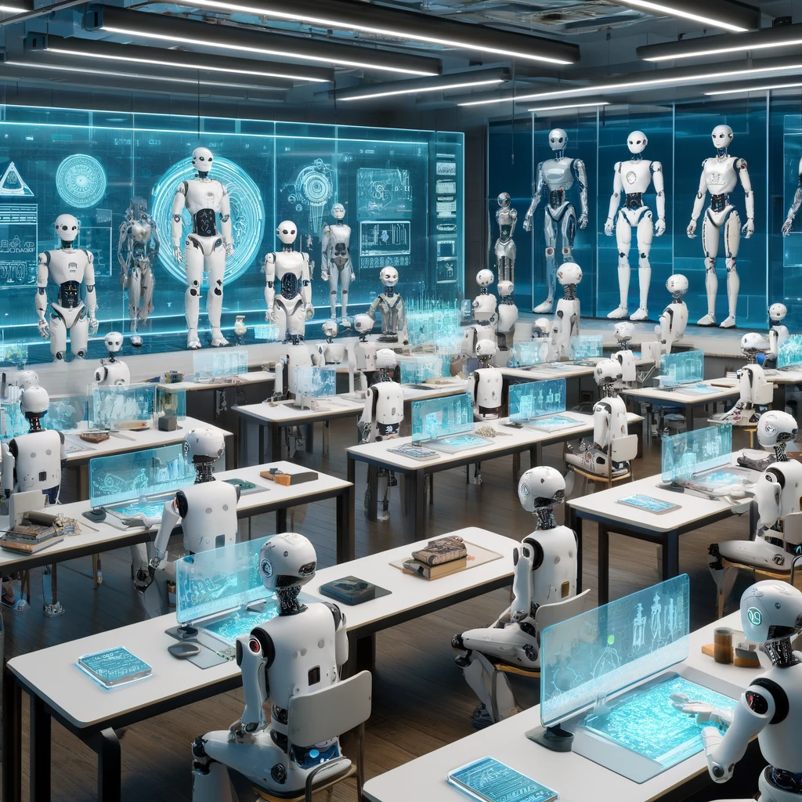

</div>

<div style="width:450px">

![robot](https://kokorokids.app/wp-content/uploads/2018/07/robot_stacking_blocks.gif)

</div>

</div>

According to Géron (2019) and Sousa (2021), **Machine Learning (ML)** is a field of Artificial
Intelligence whose goal is to program computers to **learn from data**.

For VanderPlas (2016), machine learning is about building **mathematical models that help us
understand data**. The "learning" happens when we give these models **adjustable parameters**
that are adapted to the observed data - in this sense the program is "learning" from the data.

Machine learning is one layer inside the larger field of Artificial Intelligence; Deep
Learning is a family of ML methods based on neural networks with many layers, and Generative
AI is a branch of Deep Learning.

Jordan & Mitchell (2015) describe machine learning as the question of how to build computer
systems that **improve automatically through experience**. Janiesch et al. (2021) add that,
instead of following rules written by a programmer, ML algorithms **derive the rules from
examples** - and Deep Learning is the subset of ML that uses artificial neural networks with
many layers. In remote sensing, algorithms such as SVM, Random Forest and decision trees have
become standard tools for image classification because they handle many bands and non-linear
relationships better than traditional statistical classifiers (Maxwell et al., 2018).

<div style="width:650px">

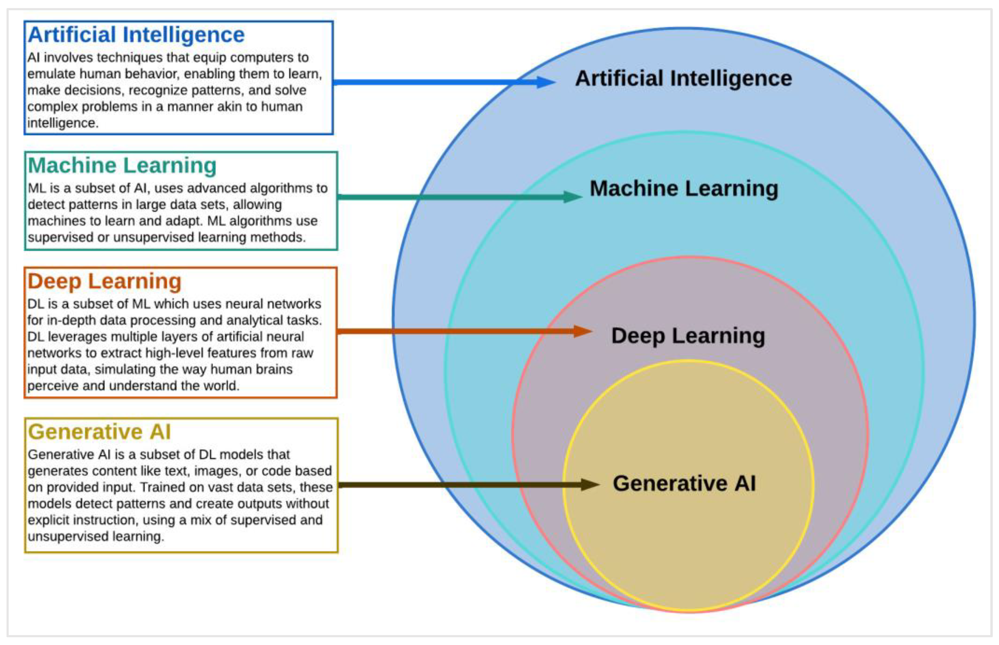

</div>

*Source: Zhuhadar & Lytras (2023), https://doi.org/10.3390/su151813484*

### Basic vocabulary

- **Dataset** - the set of data. Each piece of data is an individual **observation** (in our
  case, a **pixel** or a **sample point**).
- **Features** - each observation is described by a fixed number of characteristics
  (variables). They can be continuous, discrete or categorical. In remote sensing the features
  are the **bands** and **indices** of the image: Blue, Red, NIR, NDVI, elevation...
- **Input features and output** - example: an agricultural study measures (a) light intensity
  and (b) hours of light per day, and wants to predict **fruit production**. (a) and (b) are
  the *inputs*; fruit production is the *output*. In image classification the inputs are the
  band values of the pixel and the output is its **class** (water, soil, urban...).

### The steps of a predictive model (pipeline)

0. **Understand the problem** - which question are we answering?
1. **Understand the data** - distribution, outliers, structured or not.
2. **Exploratory analysis** - do we have all the "ingredients"?
3. **Cleaning and pre-processing** - remove outliers, no-data, clouds (Day 3!).
4. **Train the model** - split the samples into **training** and **test** (e.g. 70% / 30%).
5. **Test and evaluate** - accuracy and validation metrics.
6. **Deploy** - apply the model to the whole image and use the map.

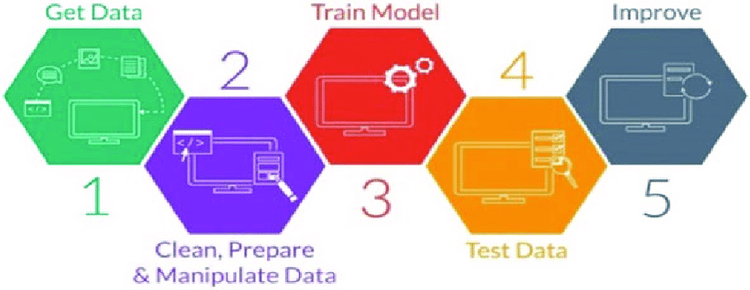

*Source: Belsare & Singh (2022)*

### How do machines learn?

<div style="width:500px">

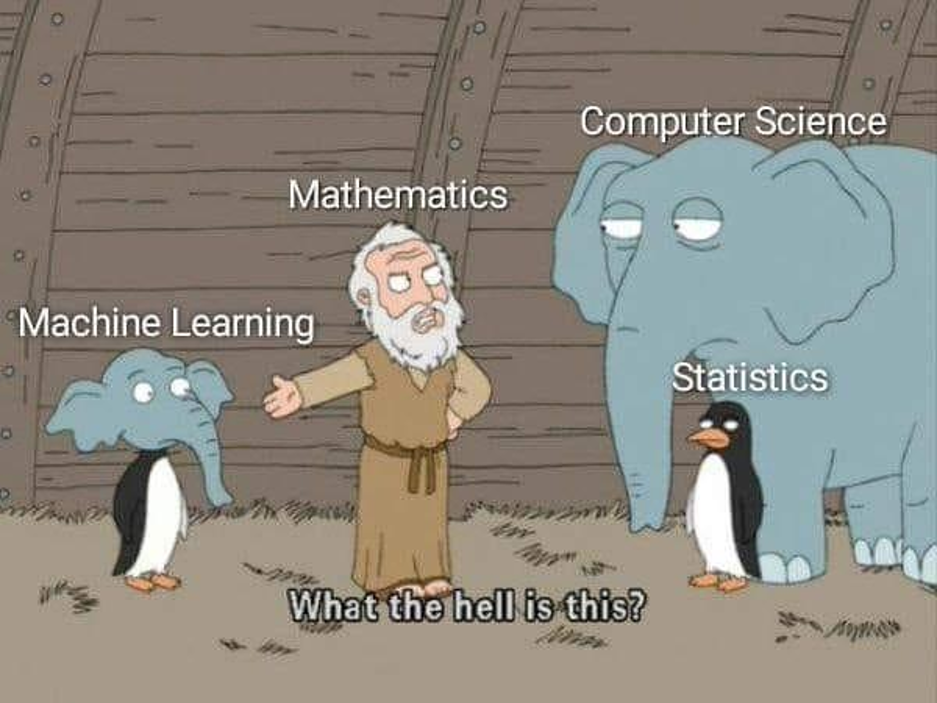

</div>


Depending on the data we give and the problem we want to solve, machines learn in three ways:

- **Supervised learning** - the data have labels (the correct answer is known).
- **Unsupervised learning** - the data have no labels; the algorithm finds structure on its own.
- **Reinforcement learning** - an agent learns by trial and error, with rewards and penalties.

Image classification uses the first two.

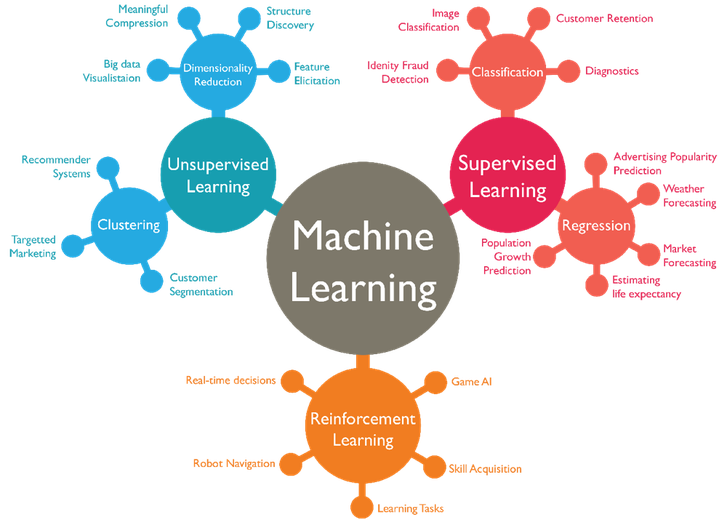

### Unsupervised learning

- Discovers **patterns and hidden structure** in the data.
- Works with **unlabelled** data (no correct outputs).
- Main families: **clustering**, **dimensionality reduction** and hierarchical analysis.

Unsupervised learning models the features of a dataset without reference to any label - it
is often described as **"letting the dataset speak for itself"** (VanderPlas, 2016).

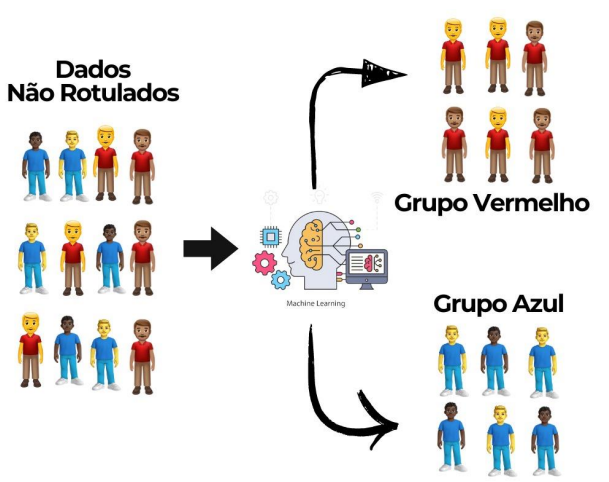

#### K-Means

K-Means splits the data into **k groups (clusters)**. It starts with k random centres, assigns
each pixel to the nearest centre, recomputes the centres as the mean of their pixels, and
repeats until the centres stop moving. The analyst only chooses **k**; the meaning of each
cluster (water? soil?) is decided **afterwards**, by looking at the map.

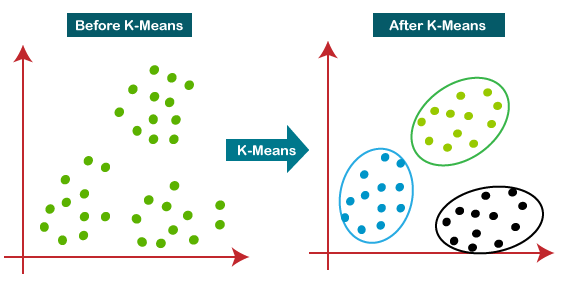

In an image, K-Means groups pixels that are close to each other in the **feature space**
(band values), not on the map. The choice of the distance (Euclidean, Manhattan) and of k
changes the result:

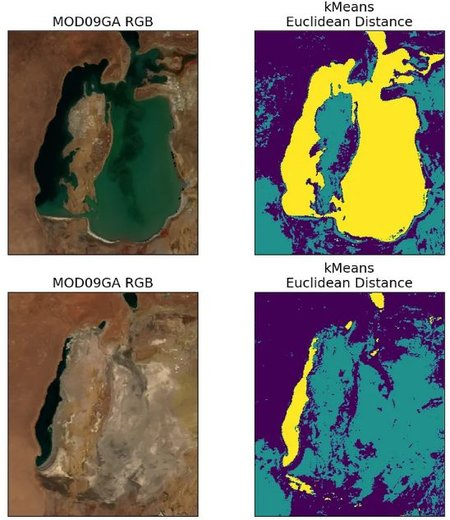
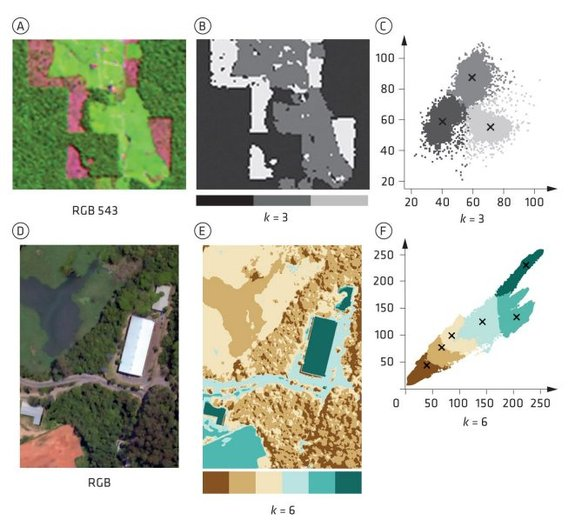

*Sources: Rozanov (2024); Zanotta et al. (2019)*

#### Principal Component Analysis (PCA)

Originally proposed by Pearson (1901), **PCA** is an exploratory tool that uses an orthogonal
transformation to convert a set of possibly **correlated** variables into new **uncorrelated**
variables, the **principal components** (Zanotta et al., 2019).

**The idea in simple words.** In a satellite image many bands carry almost the same
information. A bright pixel (sand, a roof) is bright in Blue, Green and Red at the same time;
a dark pixel (water, shadow) is dark in all of them. Plotting one band against another, the
pixels form an elongated cloud along a diagonal - the bands are **correlated**, and much of
what they say is **repeated**.

PCA **rotates the axes** of this cloud:

- **PC1** follows the longest direction of the cloud - it captures what all bands have in
  common, usually the **overall brightness** of the pixel;
- **PC2** is perpendicular to PC1 and captures the **differences between bands** - in a
  Landsat image that includes NIR, it often highlights **vegetation** (high NIR, low Red);
- the following components hold less and less information, and the last ones are mostly
  **noise**.

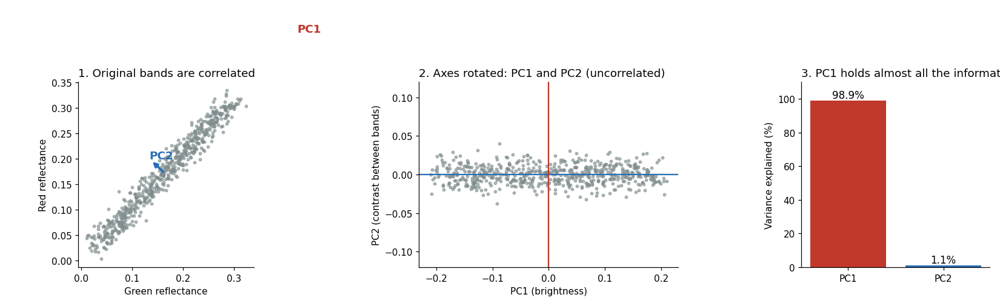

*Illustrative example with two bands (synthetic data). Elaborated by the authors.*

**Why it is useful in remote sensing:**

- **Reduce data** - 6 or 10 bands can often be summarised in 2 or 3 components with more than
  90% of the information, which makes classification faster;
- **Remove noise** - discarding the last components cleans the image;
- **Highlight contrasts** - colour composites of PC1, PC2 and PC3 reveal differences that are
  hard to see in the original bands, for example in **geological mapping**:

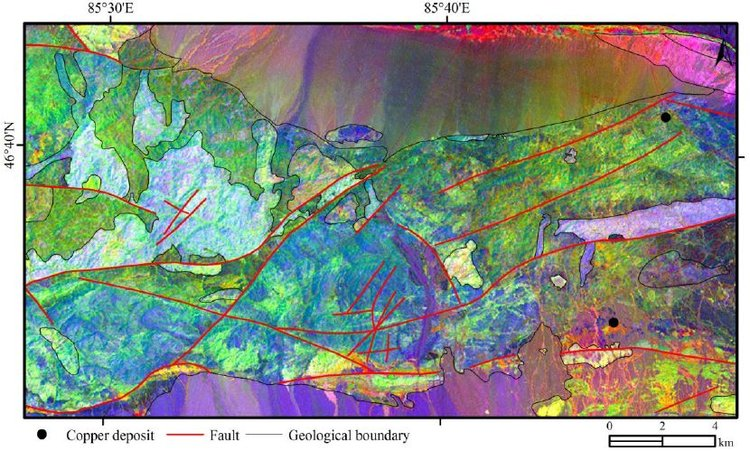

*Source: Jiang et al. (2013), Remote Sens. 5, 3156-3171, doi:10.3390/rs5073156*

> **Attention:** principal components have **no fixed physical meaning** - they are
> computed from each image, so PC2 of one scene is not the same as PC2 of another.

### Supervised learning

- Maps **inputs to pre-defined outputs** using **labelled** data.
- Used for **classification** (a category) and **regression** (a number): linear regression,
  K-Nearest Neighbours (KNN), Support Vector Machines (SVM), Random Forest and CART.

Supervised learning models the relationship between the measured features and a **label**;
once the model is fitted, it can be used to label **new, unknown data** (VanderPlas, 2016).
In training we give the model the input features **together with the expected output** - the
model learns from these input-output pairs.

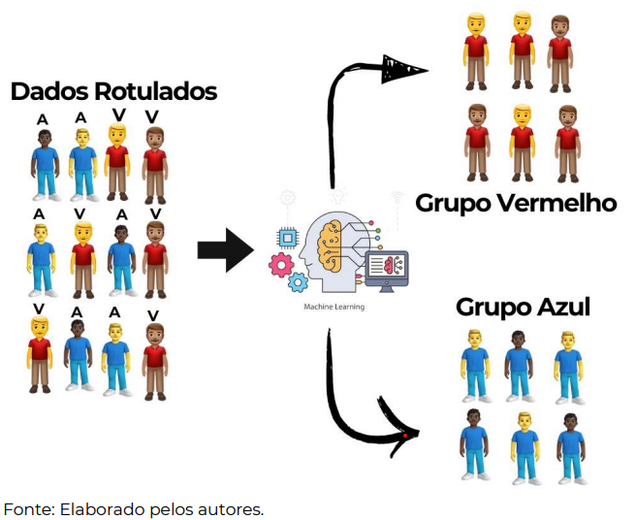
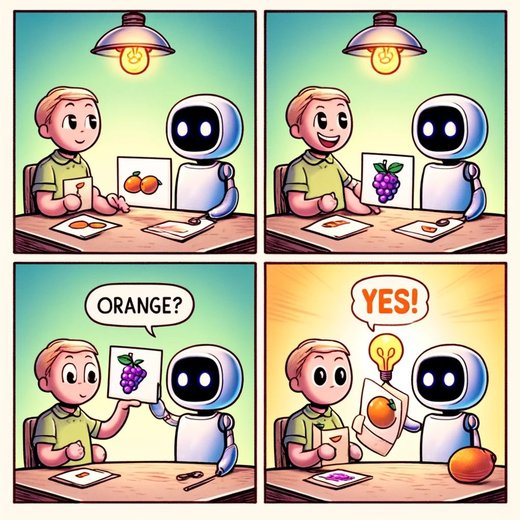

### Parameters, hyperparameters and feature importance

- **Parameters** - ML models are mathematical functions with values that are **adjusted
  during training** to reach a better performance. They are estimated **from the data**.
- **Hyperparameters** - values chosen **by the analyst** before training (number of trees,
  depth of a tree, k of K-Means...). They are not learned from the data, but they affect the
  result. A common practice is to test several values and keep the best one:

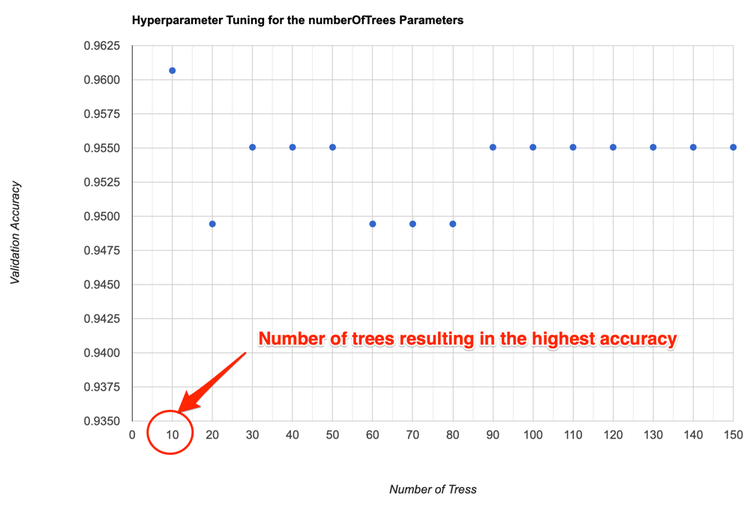

*Source: Gandhi (2021)*

- **Feature importance** - many classifiers in GEE have an `explain()` method. The classifier
  gives each input variable a **score** of how useful it was to predict the correct class.
  We will compute it at the end of this notebook.

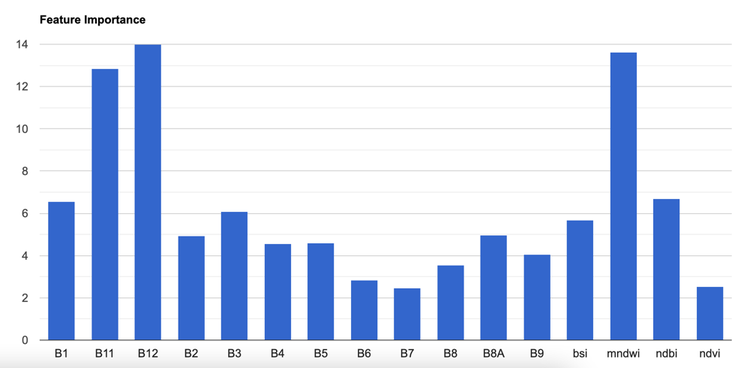

*Source: Gandhi (2021)*

---

## 1.2 - Teoria / Theory: image classification

**Classification** is the process of assigning a **label** to data described by a set of
attributes. In remote sensing images this means deciding, **for each pixel**, which category is
on the ground - water, soil, forest... - usually from its **spectral attributes**, the value
in each band (Jensen, 2005; Zanotta et al., 2019).

| | |
|:---:|:---:|
| 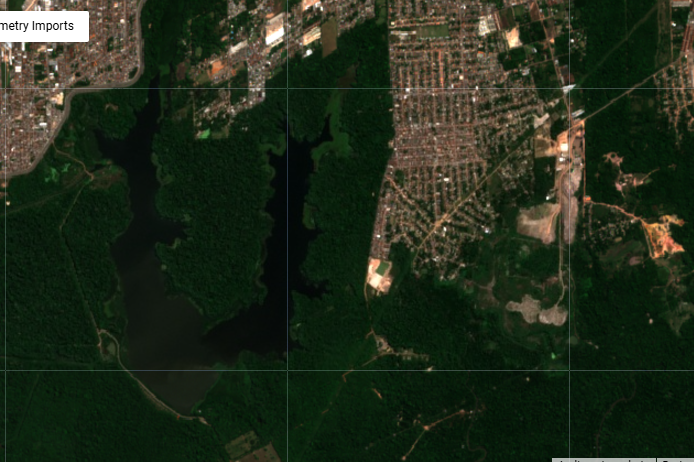 | 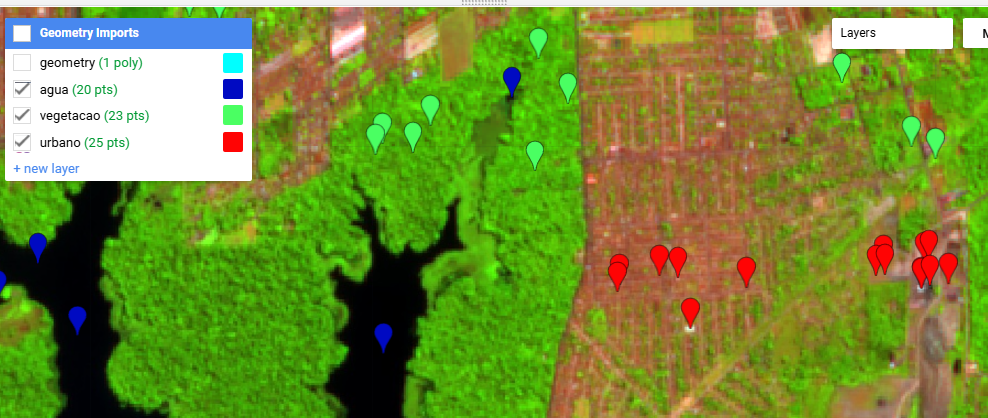 |
| 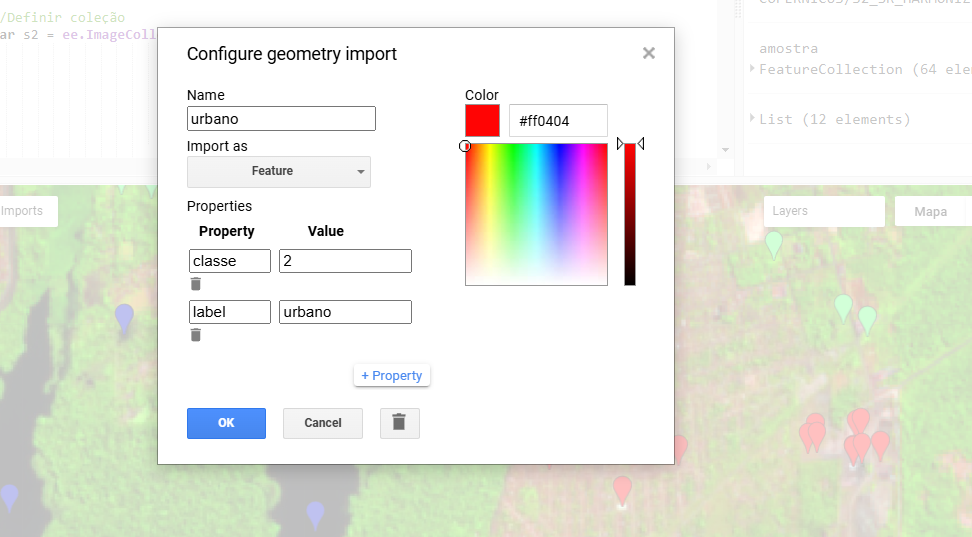 | 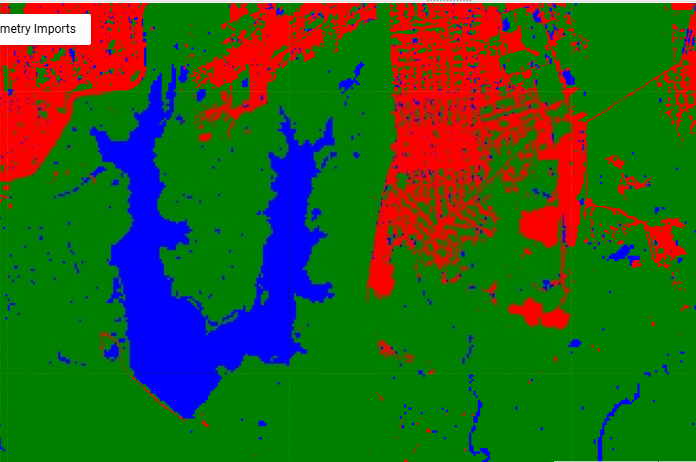 |

Each pixel is a point in the **feature space** (one axis per band). Pixels of the same class
form clouds of points; the classifier draws the **boundaries** between these clouds.

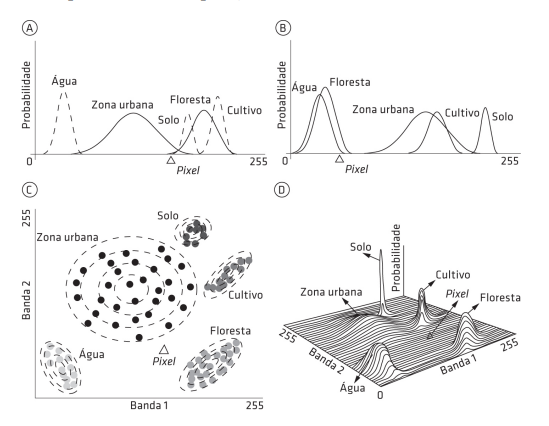

*Source: Zanotta et al. (2019)*

### Examples of classifiers

**Minimum (Euclidean) distance** - uses only the **mean** of each class in the feature space.
A pixel is assigned to the class whose mean is the closest.

**Maximum likelihood (MaxVer)** - models each class as a Gaussian distribution. The winning
class is the one with the **highest joint probability** (height of the Gaussian curve) across
all bands.

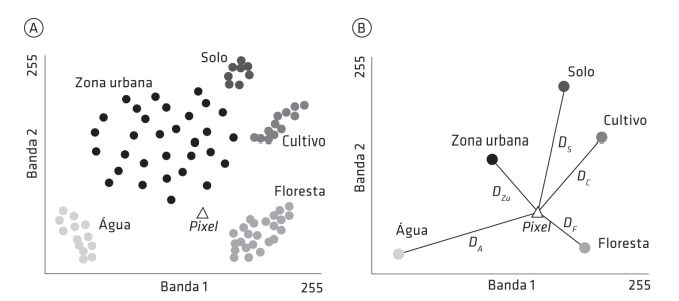

*Source: Zanotta et al. (2019)*

**KNN - k nearest neighbours** - one of the simplest and most intuitive algorithms. Each new
sample receives the **majority class among its k nearest neighbours** in the feature space.

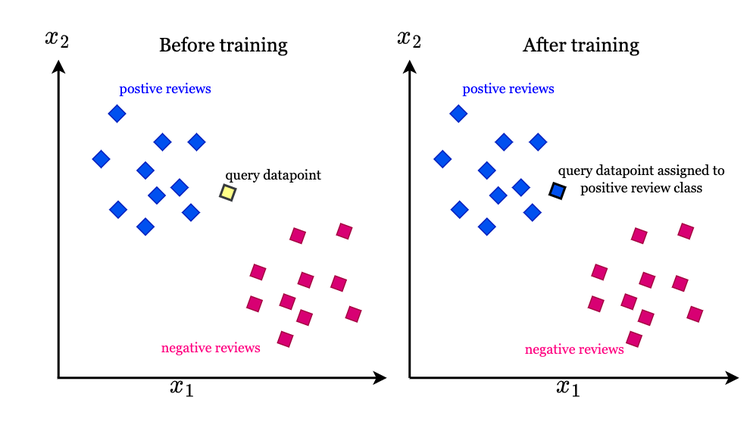

**SVM - Support Vector Machine** - searches for a **hyperplane** that separates the classes,
with the **maximum margin**: the boundary that is as far as possible from the closest training
samples (the *support vectors*). With a non-linear formulation (kernel, e.g. RBF) it can draw
curved boundaries and learn complex functions. SVM is sensitive to the **scale** of the
features, so the bands should be standardised.

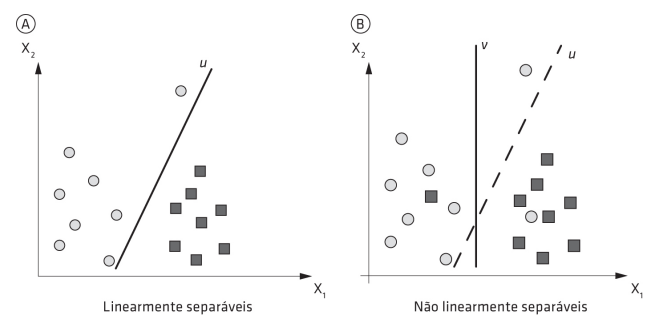

*Source: Zanotta et al. (2019)*

**Decision tree (CART)** - splits the input attributes **sequentially** into subspaces that
isolate the classes. The problem is broken into simple decisions - objective questions such as
*"is NDVI > 0.5?"* - solved recursively until each leaf holds one class.

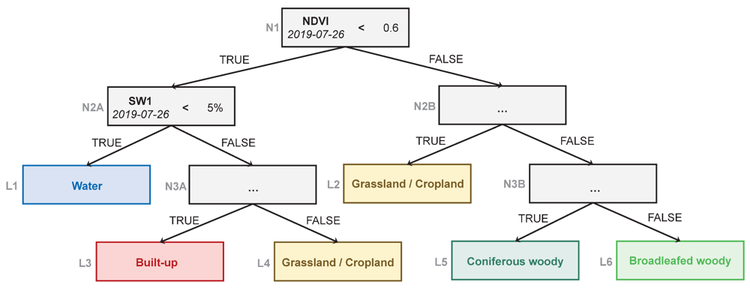

**Random Forest** - proposed by Breiman (2001), widely used in machine learning and very
successful in remote sensing. It **combines many decision trees**, each trained on a different
random subset of the samples and of the variables. The final class is decided by **majority
vote**. This makes it robust to noise and to overfitting, and it also gives the importance of
each variable.

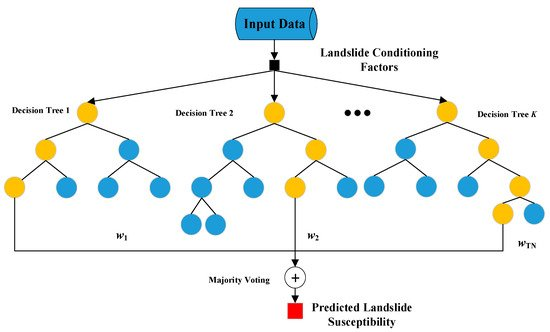

*Source: Dang (2020)*

---

## 1.3 - Teoria / Theory: accuracy assessment

The samples are **split** into a **training** set (used to teach the classifier) and a
**test** set (kept apart, never seen by the classifier). The test labels are compared with
the predicted classes.

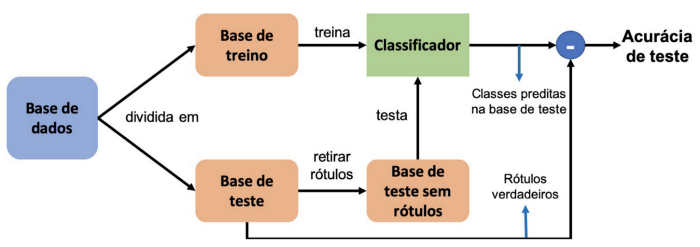

*Source: Escovedo & Koshiyama (2020)*

For each class we count the samples correctly detected and the samples wrongly assigned to it.
These results are organised in a **confusion matrix** (error matrix): in GEE the **rows are the
reference** (test samples) and the **columns are the classification**.

| Metric | Question it answers | How it is computed |
|---|---|---|
| **Overall accuracy (OA)** | What percentage of the samples is correct? | diagonal sum / total |
| **Consumer's accuracy (user's)** | If the **map** says "water", how likely is it really water? | diagonal / **column** total |
| **Producer's accuracy** | Of the real water samples, how many were mapped as water? | diagonal / **row** total |
| **Commission error** | Pixels **wrongly included** in a class | 1 - consumer's accuracy |
| **Omission error** | Pixels of a class that were **left out** | 1 - producer's accuracy |
| **Kappa** | Agreement beyond what chance would give | from the whole matrix |

**Spatial autocorrelation.** Neighbouring pixels are very similar. If a training pixel and a
test pixel come from the same field, the test is too easy and the accuracy is **inflated**.
That is why we split the **sample geometries** (points or polygons) into training and test
**before** extracting the pixels.

---

## 1.4 - Practica guiada / Guided hands-on: setup and the data cube

The study area has two parts on the shore of **Lake Titicaca**: one near **Puno** (Peru) and one
on the Bolivian side. We use only five classes:

**Water, Vegetation, Soil, Urban and Agriculture**

In [ ]:
# Libraries (uncomment the pip line on a fresh runtime, e.g. Google Colab)
#%pip install -q earthengine-api geemap

import os
import ee                          # Google Earth Engine API
import geemap                      # interactive maps for Earth Engine
import pandas as pd                # tables (DataFrames)
import matplotlib.pyplot as plt    # charts
import seaborn as sns              # heatmap of the confusion matrix

In [ ]:
# Authenticate and initialise Earth Engine
# >>> REPLACE with your own Cloud project id <<<
EE_PROJECT = "ee-christhianscunha"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

In [ ]:
# Study area: two rectangles on the shore of Lake Titicaca
REGION =  ee.Geometry.Polygon(
        [[[-69.1010932684908, -16.14842858486395],
          [-69.1010932684908, -16.17175891406604],
          [-69.06075284490682, -16.17175891406604],
          [-69.06075284490682, -16.14842858486395]]], None, False);
Map = geemap.Map()
Map.centerObject(REGION, 12)
Map.add_basemap("SATELLITE")
Map.addLayer(REGION, {"color": "red"}, "Study area")
Map

### The data cube (from Day 3)

The same three functions of Day 3: cloud mask, scale factor and indices. With them we build a
**median composite** of the dry season (May-September), when the sky over the altiplano is
clear. The median of many dates removes the remaining clouds and noise.

In [ ]:
def mask_clouds(image):
    # QA_PIXEL bits 1 (dilated cloud), 2 (cirrus), 3 (cloud) and 4 (cloud shadow)
    cloud_bits = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4)
    clear = image.select("QA_PIXEL").bitwiseAnd(cloud_bits).eq(0)
    return image.updateMask(clear)


def scale_and_rename(image):
    # Collection 2 scale factor -> surface reflectance, and readable band names
    optical = image.select(["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
    optical = optical.multiply(0.0000275).add(-0.2)
    return optical.rename(["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"])


def add_indices(image):
    ndvi = image.normalizedDifference(["NIR", "Red"]).rename("NDVI")
    ndwi = image.normalizedDifference(["Green", "NIR"]).rename("NDWI")
    ndmi = image.normalizedDifference(["NIR", "SWIR1"]).rename("NDMI")
    evi = image.expression(
        "2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)",
        {"NIR": image.select("NIR"), "RED": image.select("Red"), "BLUE": image.select("Blue")},
    ).rename("EVI")
    msavi = image.expression(
        "(2 * NIR + 1 - sqrt((2 * NIR + 1) ** 2 - 8 * (NIR - RED))) / 2",
        {"NIR": image.select("NIR"), "RED": image.select("Red")},
    ).rename("MSAVI")
    return image.addBands([ndvi, msavi, evi, ndwi, ndmi])

In [ ]:
# Landsat 8 + 9, dry season 2024, over the study area
collection = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
                .filterBounds(REGION)
                .filterDate("2024-05-01", "2024-09-30")
                .filter(ee.Filter.lt("CLOUD_COVER", 30))
                .map(mask_clouds)
                .map(scale_and_rename)
                .map(add_indices))

# Median composite: one value per pixel and band
composite = collection.median()

print("Images used in the composite:", collection.size().getInfo())

### Adding elevation and slope (NASADEM)

Some classes are hard to separate with spectral information only - for example agriculture
on flat terraces versus natural vegetation on steep hills. Adding **elevation** and **slope**
from the NASADEM digital elevation model (30 m) gives the classifier this extra information.

In [ ]:
# Elevation (m) and slope (degrees) from NASADEM
elevation = ee.Image("NASA/NASADEM_HGT/001").select("elevation")
slope = ee.Terrain.slope(elevation).rename("slope")

# The final image: 6 bands + 5 indices + elevation + slope
image = composite.addBands([elevation, slope]).toFloat()

FEATURES = image.bandNames().getInfo()
print("Features:", FEATURES)

### Standardising the features

Reflectance goes from 0 to ~0.5, NDVI from -1 to 1, elevation from ~3800 to ~4500 m. Methods
based on **distance** (K-Means, SVM) would be dominated by elevation just because its numbers
are bigger. We **standardise** each band: subtract its mean and divide by its standard
deviation, so all features have mean 0 and standard deviation 1.

CART and Random Forest do not need this, but using the same standardised image for all
methods keeps the comparison fair.

In [ ]:
# Mean and standard deviation of every band over the study area
mean = image.reduceRegion(ee.Reducer.mean(), REGION, 30, maxPixels=1e9)
std = image.reduceRegion(ee.Reducer.stdDev(), REGION, 30, maxPixels=1e9)

# (value - mean) / std, band by band
image_std = image.subtract(mean.toImage(FEATURES)).divide(std.toImage(FEATURES))

# Visualisation of the real (not standardised) image
vis_rgb = {"bands": ["Red", "Green", "Blue"], "min": 0.0, "max": 0.3}
vis_false = {"bands": ["NIR", "Red", "Green"], "min": 0.0, "max": 0.4}

Map = geemap.Map()
Map.centerObject(REGION,14)
Map.addLayer(image.clip(REGION), vis_rgb, "RGB composite")
Map.addLayer(image.clip(REGION), vis_false, "False colour (NIR-R-G)", False)
Map

---

## 1.5 - Clasificacion no supervisada / Unsupervised classification: K-Means

Three steps:

1. take a **random sample** of pixels from the image (no labels!);
2. **train** the clusterer, choosing only the number of clusters (k = 5, one per class we
   expect);
3. apply it to the whole image with `cluster()`.

The result is a map of **clusters numbered 0 to 4**. The numbers have **no meaning** until
we interpret them by comparing with the RGB image.

In [ ]:
# 1. Random sample of 5000 pixels from the study area
kmeans_sample = image_std.sample(region=REGION, scale=30, numPixels=5000, seed=42)

# 2. Train K-Means with k = 5 clusters
kmeans = ee.Clusterer.wekaKMeans(5).train(kmeans_sample)

# 3. Apply it to every pixel
clusters = image_std.cluster(kmeans).clip(REGION)

Map = geemap.Map()
Map.centerObject(REGION, 14)
Map.addLayer(image.clip(REGION), vis_rgb, "RGB composite")
Map.addLayer(clusters.randomVisualizer(), {}, "K-Means (5 clusters)")
Map

**Question.** Switch the K-Means layer on and off. Which cluster is water? Does one cluster
mix urban and soil? K-Means finds the groups that are **spectrally** different, which are not
always the classes **we** want. That is the motivation for supervised classification.

---

## 1.6 - Clasificacion supervisada / Supervised classification

### Loading the samples

The samples were collected in the
[TRANSCEND Sample Collector](https://ee-christhianscunha.projects.earthengine.app/view/transcend-samplecollector)
and exported as **GeoJSON**. Each sample stores the **class code** (a number) and the
**class name**.

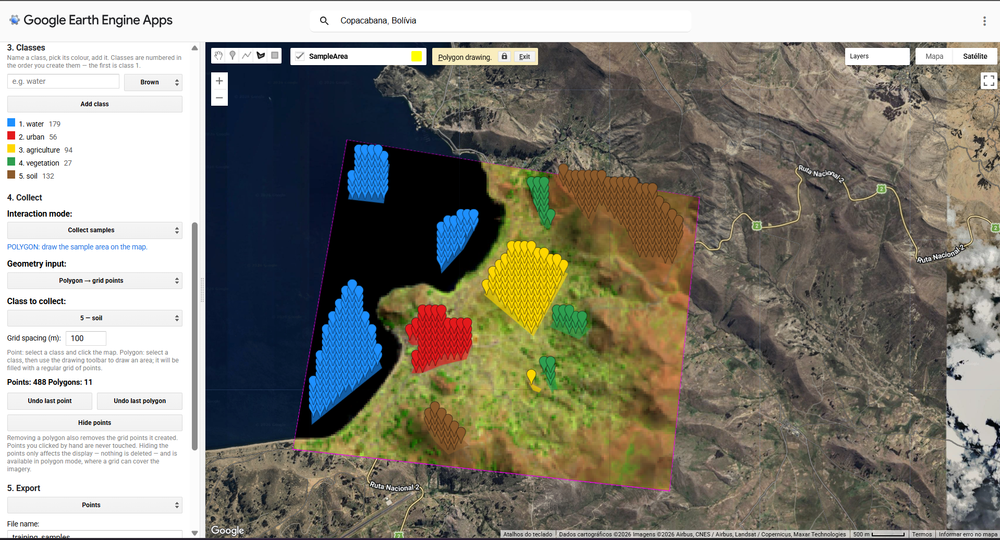

1. Upload the GeoJSON to the working folder (in Colab: the folder icon on the left -> upload).
2. Check the name of the file and of the two attributes below.
3. `geemap.geojson_to_ee()` converts the file into an `ee.FeatureCollection` that Earth
   Engine can use.

> If the file is not found, the next cell creates **demonstration samples** from the ESA
> WorldCover map, so the notebook still runs. Use your own samples for the exercise.

In [ ]:
# >>> Adjust to your file <<<
SAMPLES_FILE = r"C:\Users\b61237cs\Documents\TRANSCEND\SummerSchool\Assets\Day4\copacabana_samples.geojson"   # GeoJSON exported from the Sample Collector
CLASS_PROPERTY = "class"                     # attribute with the class code (number)
NAME_PROPERTY = "class_name"                       # attribute with the class name

if os.path.exists(SAMPLES_FILE):
    # GeoJSON -> ee.FeatureCollection
    samples = geemap.geojson_to_ee(SAMPLES_FILE)
else:
    # Demonstration samples: random points per class from ESA WorldCover 2021
    # WorldCover codes -> our classes: 80 water=1 | 10,20,30 vegetation=2 | 60 soil=3 | 50 urban=4 | 40 crops=5
    print("GeoJSON not found - using demonstration samples from ESA WorldCover")
    worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()
    reference = worldcover.remap([80, 10, 20, 30, 60, 50, 40], [1, 2, 2, 2, 3, 4, 5]).rename(CLASS_PROPERTY)
    samples = reference.stratifiedSample(numPoints=60, classBand=CLASS_PROPERTY, region=REGION,
                                         scale=30, seed=42, geometries=True)
    names = ee.Dictionary({"1": "Water", "2": "Vegetation", "3": "Soil", "4": "Urban", "5": "Agriculture"})
    samples = samples.map(lambda f: f.set(NAME_PROPERTY, names.get(ee.Number(f.get(CLASS_PROPERTY)).int().format())))

print("Number of samples:", samples.size().getInfo())
samples.limit(5)

In [ ]:
# The samples as a DataFrame, to check the attributes
df_samples = geemap.ee_to_df(samples)

# Class codes and names, in order of the code
classes = (df_samples[[CLASS_PROPERTY, NAME_PROPERTY]]
           .drop_duplicates()
           .sort_values(CLASS_PROPERTY)
           .reset_index(drop=True))

CLASS_CODES = classes[CLASS_PROPERTY].astype(int).tolist()
CLASS_NAMES = classes[NAME_PROPERTY].tolist()

# One colour per class, in the same order as the codes
# (water, vegetation, soil, urban, agriculture - change if your codes are in another order)
PALETTE = ["#2c7bb6", "#a21616", "#d8b365", "#2ae01a", "#cc7218f3"]

classes["colour"] = PALETTE[:len(classes)]
classes

### Training and test samples

We split the **samples (geometries)** randomly: **70% for training** and **30% for test**.
Only then do we extract the pixel values with `sampleRegions`: for each sample, the value of
the 13 features and the class code. This produces a table - exactly the *dataset* of the
theory: rows are observations, columns are features and the label.

In [ ]:
# Random number between 0 and 1 for each sample, then split 70 / 30
samples = samples.randomColumn("random", seed=42)
train_samples = samples.filter(ee.Filter.lt("random", 0.7))
test_samples = samples.filter(ee.Filter.gte("random", 0.7))

# Extract the pixel values of the features under each sample
train = image_std.sampleRegions(collection=train_samples, properties=[CLASS_PROPERTY],
                                scale=30, tileScale=4)
test = image_std.sampleRegions(collection=test_samples, properties=[CLASS_PROPERTY],
                               scale=30, tileScale=4)

# Number of pixels per class in each set
pd.DataFrame({"train": train.aggregate_histogram(CLASS_PROPERTY).getInfo(),
              "test": test.aggregate_histogram(CLASS_PROPERTY).getInfo()})

In [ ]:
# A look at the training table: one row per pixel, one column per feature (standardised)
geemap.ee_to_df(train.limit(5))

In [ ]:
# Show the training and test samples on the map
Map = geemap.Map()
Map.centerObject(REGION, 9)
Map.addLayer(image.clip(REGION), vis_rgb, "RGB composite")
Map.addLayer(train_samples, {"color": "yellow"}, "Training samples")
Map.addLayer(test_samples, {"color": "magenta"}, "Test samples")
Map

### Spatial autocorrelation: keeping training and test apart

Look at the map above: some **yellow** (training) points are right next to **magenta** (test)
points. Neighbouring pixels are almost identical, so testing on a pixel whose neighbour was
used in training is like giving the students the exam answers in advance - the accuracy
looks better than it really is.

The [Earth Engine classification guide](https://developers.google.com/earth-engine/guides/classification)
proposes a simple solution:

> *"One way to exclude samples that might be correlated in this manner is to remove samples
> that are within some distance to any other sample(s). This can be accomplished with a
> spatial join."*

We keep the **test** samples as they are and **remove the training samples that are closer
than `MIN_DISTANCE` metres to any test sample**:

- `ee.Filter.withinDistance` - the rule "closer than X metres";
- `ee.Join.inverted()` - keeps only the training samples that do **not** meet that rule.

In [ ]:
MIN_DISTANCE = 110   # metres - try 50, 100 or 300 and see how many samples remain

# Rule: two geometries closer than MIN_DISTANCE
too_close = ee.Filter.withinDistance(distance=MIN_DISTANCE, leftField=".geo",
                                     rightField=".geo", maxError=10)

# Training samples far from every test sample (kept) and close to one (removed)
train_samples_far = ee.Join.inverted().apply(train_samples, test_samples, too_close)
train_samples_removed = ee.Join.simple().apply(train_samples, test_samples, too_close)

print("Training samples before:", train_samples.size().getInfo())
print("Training samples after :", train_samples_far.size().getInfo())

In [ ]:
# The same map, now without the training samples that were too close to a test sample
Map = geemap.Map()
Map.centerObject(REGION, 9)
Map.addLayer(image.clip(REGION), vis_rgb, "RGB composite")
Map.addLayer(train_samples_far, {"color": "#ffff00"}, "Training samples (kept)")
Map.addLayer(test_samples, {"color": "#ff00ff"}, "Test samples")
Map.addLayer(train_samples_removed, {"color": "#ff0000"}, "Training samples removed (too close)")
Map.add_legend(title="Samples", legend_dict={"Training (kept)": "#ffff00", "Test": "#ff00ff",
                                             "Removed (too close)": "#ff0000"})
Map

Compare the two maps: the **red** points are the training samples that were too close to a
test sample. From here on we train with the **spatially separated** samples. The test samples
do not change.

> Choose a distance that still leaves **every class** with enough training samples - check the
> table below. A class with no samples cannot be predicted.

In [ ]:
# Extract the pixel values again, now only for the separated training samples
train = image_std.sampleRegions(collection=train_samples_far, properties=[CLASS_PROPERTY],
                                scale=30, tileScale=4)

# Number of pixels per class in each set
pd.DataFrame({"train": train.aggregate_histogram(CLASS_PROPERTY).getInfo(),
              "test": test.aggregate_histogram(CLASS_PROPERTY).getInfo()})

### A function to show each classification

The three classifiers follow the **same three steps**: create the classifier, `train()` it with
the training table, and `classify()` the image. To show the three maps the same way, we write
the map once as a function.

In [ ]:
# Visualisation of the classes
vis_classes = {"min": min(CLASS_CODES), "max": max(CLASS_CODES), "palette": PALETTE}


def show_classification(classified, title):
    m = geemap.Map()
    m.centerObject(REGION, 14)
    m.addLayer(image.clip(REGION), vis_rgb, "RGB composite")
    m.addLayer(classified, vis_classes, title)
    m.add_legend(title=title, legend_dict=dict(zip(CLASS_NAMES, PALETTE)))
    return m

### CART - decision tree

`ee.Classifier.smileCart()` builds a single decision tree with rules on the features.

In [ ]:
# Create and train the classifier
cart = ee.Classifier.smileCart().train(
    features=train, classProperty=CLASS_PROPERTY, inputProperties=FEATURES)

# Classify the image
classified_cart = image_std.classify(cart).clip(REGION)

show_classification(classified_cart, "CART")

### SVM - Support Vector Machine

`ee.Classifier.libsvm()` with an **RBF kernel** (curved boundaries). Two hyperparameters:

- `gamma` - how far the influence of each sample reaches (high = very local boundaries);
- `cost` - how much the model penalises training errors (high = less tolerant, risk of
  overfitting).

In [ ]:
# Create and train the classifier
svm = ee.Classifier.libsvm(kernelType="RBF", gamma=0.1, cost=10).train(
    features=train, classProperty=CLASS_PROPERTY, inputProperties=FEATURES)

# Classify the image
classified_svm = image_std.classify(svm).clip(REGION)

show_classification(classified_svm, "SVM")

### Random Forest

`ee.Classifier.smileRandomForest()` with **100 trees**. The `seed` fixes the random choices,
so everyone in the class gets the same result.

In [ ]:
# Create and train the classifier
rf = ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42).train(
    features=train, classProperty=CLASS_PROPERTY, inputProperties=FEATURES)

# Classify the image
classified_rf = image_std.classify(rf).clip(REGION)

show_classification(classified_rf, "Random Forest")

**Compare the three maps.** Where do they agree? Where do they differ - shoreline, the edge of
the town, the hills? The differences show where the classes are **spectrally confused**.

---

## 1.7 - Evaluacion / Accuracy assessment of the Random Forest

We classify the **test** pixels - never seen in training - and compare the prediction with the
true class. `errorMatrix(true, predicted, order)` builds the confusion matrix.

In [ ]:
# Classify the test table and build the confusion matrix
test_rf = test.classify(rf)
cm = test_rf.errorMatrix(CLASS_PROPERTY, "classification", CLASS_CODES)

print("Overall accuracy:", round(cm.accuracy().getInfo(), 3))
print("Kappa           :", round(cm.kappa().getInfo(), 3))

In [ ]:
# Confusion matrix as a DataFrame: rows = reference (test), columns = classification
df_cm = pd.DataFrame(cm.array().getInfo(), index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion matrix - Random Forest (test samples)")
ax.set_xlabel("Classification (predicted)")
ax.set_ylabel("Reference (test samples)")
plt.show()

In [ ]:
# Producer's and consumer's accuracy per class, and the corresponding errors
df_acc = pd.DataFrame({
    "Producer's accuracy": cm.producersAccuracy().project([0]).getInfo(),   # by row
    "Consumer's accuracy": cm.consumersAccuracy().project([1]).getInfo(),   # by column
}, index=CLASS_NAMES)

df_acc["Omission error"] = 1 - df_acc["Producer's accuracy"]
df_acc["Commission error"] = 1 - df_acc["Consumer's accuracy"]
df_acc.round(3)

In [ ]:
# Producer's vs consumer's accuracy per class
ax = df_acc[["Producer's accuracy", "Consumer's accuracy"]].plot.bar(
    figsize=(8, 4), color=["#4c72b0", "#dd8452"], rot=0)
ax.set_title("Accuracy per class - Random Forest")
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy (0-1)")
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**How to read it.** A class with **low producer's accuracy** is being *missed* (omission): its
pixels end up in another class. A class with **low consumer's accuracy** is *receiving* pixels
of other classes (commission): the map shows more of it than there really is. Find the cell
outside the diagonal with the largest number - that is the pair of classes most confused.

### The three classifiers side by side

The same test set, the same metric:

In [ ]:
# Overall accuracy of each classifier on the same test samples
classifiers = {"CART": cart, "SVM": svm, "Random Forest": rf}

overall = {name: test.classify(c).errorMatrix(CLASS_PROPERTY, "classification", CLASS_CODES)
                     .accuracy().getInfo()
           for name, c in classifiers.items()}

pd.DataFrame({"Overall accuracy": overall}).round(3)

---

## 1.8 - Importancia de las variables / Feature importance (Random Forest)

`rf.explain()` returns a dictionary with information about the trained model, including the
**importance** of each feature: how much it helped the trees separate the classes. We convert
it to percentage and plot it.

In [ ]:
# Importance of each feature, from the trained Random Forest
importance = ee.Dictionary(rf.explain()).get("importance").getInfo()

# To a pandas Series, in percentage, sorted
df_imp = pd.Series(importance)
df_imp = (100 * df_imp / df_imp.sum()).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_imp.index, df_imp.values, color="#2e8b57")
ax.set_title("Feature importance - Random Forest")
ax.set_xlabel("Relative importance (%)")
ax.set_ylabel("Feature")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Questions.** Are the indices more important than the original bands? Did **elevation** or
**slope** help? Features with very low importance can be removed - a simpler model is faster
and often just as accurate.

---

## 1.9 - Ejercicio / Exercise

1. **K-Means.** Change k to 3 and to 8. Which value gives clusters closest to our five
   classes?
2. **Your samples.** Collect new samples in the Sample Collector for the class with the
   **lowest producer's accuracy**, export the GeoJSON again and re-run section 1.6 and 1.7.
   Did the accuracy improve?
3. **Hyperparameters.** Train Random Forest with 10, 50 and 200 trees, and SVM with
   `gamma` 0.01, 0.1 and 1. Make a small table with the overall accuracy of each.
4. **Fewer features.** Keep only the 6 most important features of section 1.8 and train the
   Random Forest again. What happens to the accuracy?

**Entregable / Deliverable**: the notebook with the maps, the tables of questions 3 and 4, and a
short paragraph explaining which classifier you would choose and why.

---

## Referencias / References

**Machine learning and classification**

- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32.
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
- VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly.
  <https://jakevdp.github.io/PythonDataScienceHandbook/05.01-what-is-machine-learning.html>
- Zanotta, D., Zortea, M., Ferreira, M. P. (2019). *Processamento de imagens de satélite*.
  São Paulo: Oficina de Textos.
- Jensen, J. R. (2005). *Introductory Digital Image Processing: A Remote Sensing Perspective*.
  Prentice Hall.
- Belsare, K., Singh, M. (2022). Machine learning approaches and the Internet of Things.
- Zhuhadar, L. P., Lytras, M. D. (2023). The application of AutoML techniques in diabetes
  diagnosis. *Sustainability*, 15(18), 13484. <https://doi.org/10.3390/su151813484>
- Jiang, D. et al. (2013). *Remote Sensing*, 5, 3156-3171. <https://doi.org/10.3390/rs5073156>
- Escovedo, T., Koshiyama, A. (2020). *Introdução a Data Science*. Casa do Código.
  <https://tatianaesc.medium.com/machine-learning-conceitos-e-modelos-f0373bf4f445>
- Souza, C. M. et al. (2020). Reconstructing three decades of land use and land cover changes in
  Brazilian biomes with Landsat archive and Earth Engine. *Remote Sensing*, 12(17), 2735.
  <https://doi.org/10.3390/rs12172735>
- Jordan, M. I., Mitchell, T. M. (2015). Machine learning: Trends, perspectives, and prospects.
  *Science*, 349(6245), 255-260. <https://doi.org/10.1126/science.aaa8415>
- Janiesch, C., Zschech, P., Heinrich, K. (2021). Machine learning and deep learning.
  *Electronic Markets*, 31, 685-695. <https://doi.org/10.1007/s12525-021-00475-2>
- Sarker, I. H. (2021). Machine learning: Algorithms, real-world applications and research
  directions. *SN Computer Science*, 2, 160. <https://doi.org/10.1007/s42979-021-00592-x>
- Maxwell, A. E., Warner, T. A., Fang, F. (2018). Implementation of machine-learning
  classification in remote sensing: an applied review. *International Journal of Remote
  Sensing*, 39(9), 2784-2817. <https://doi.org/10.1080/01431161.2018.1433343>

**Google Earth Engine**

- Gandhi, U. (2021). *End-to-End Google Earth Engine* (Supervised classification, feature
  importance, hyperparameter tuning). <https://courses.spatialthoughts.com/end-to-end-gee.html>
- Supervised classification: <https://developers.google.com/earth-engine/guides/classification>
- Unsupervised classification: <https://developers.google.com/earth-engine/guides/clustering>
- NASADEM: <https://developers.google.com/earth-engine/datasets/catalog/NASA_NASADEM_HGT_001>
- ESA WorldCover: <https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200>
- geemap: <https://geemap.org>